In [1]:
import os
import csv
import json
import random
import hashlib
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import torchvision.transforms as T
import timm

from sklearn.metrics import f1_score, recall_score, accuracy_score, confusion_matrix

In [2]:
DEBUG = False

SEED = 42
IMG_SIZE = 224
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = len(CLASSES)

RAW_ROOT = Path("data/raw/Epic and CSCR hospital Dataset")
SPLIT_DIR = Path("data/splits")
CKPT_DIR = Path("outputs/checkpoints")
RESULTS_DIR = Path("outputs/results")
FIG_DIR = Path("outputs/figures")
for d in [SPLIT_DIR, CKPT_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

CONFIG = {
    "effnet":  {"arch": "efficientnet_b0",  "type": "single", "epochs": 1 if DEBUG else 10, "batch_size": 32, "lr": 3e-4},
    "swin":    {"arch": "swin_tiny_patch4_window7_224", "type": "single", "epochs": 1 if DEBUG else 10, "batch_size": 24, "lr": 3e-4},
    "hybrid":  {"arch": "hybrid", "type": "hybrid", "epochs": 1 if DEBUG else 12, "batch_size": 24, "lr": 2e-4, "backbone_lr": 5e-5},
    "coatnet": {"arch": "coatnet_0_rw_224", "type": "single", "epochs": 1 if DEBUG else 10, "batch_size": 32, "lr": 3e-4},
}


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()

Device: cuda NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
VAL_FRACTION = 0.15


def file_hash(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def collect_split(split: str):
    by_hash, dup_count = {}, 0
    for cls in CLASSES:
        folder = RAW_ROOT / split / cls
        for p in sorted(folder.glob("*")):
            if not p.is_file():
                continue
            h = file_hash(p)
            if h in by_hash:
                dup_count += 1
                continue
            by_hash[h] = (p, cls)
    return by_hash, dup_count


def build_splits():
    set_seed()
    train_hashes, train_dups = collect_split("Train")
    test_hashes, test_dups = collect_split("Test")

    overlap = set(train_hashes) & set(test_hashes)
    for h in overlap:
        del train_hashes[h]

    by_class = defaultdict(list)
    for h, (path, cls) in train_hashes.items():
        by_class[cls].append(path)

    train_rows, val_rows = [], []
    for cls, paths in by_class.items():
        paths = sorted(paths)
        random.shuffle(paths)
        n_val = max(1, int(len(paths) * VAL_FRACTION))
        val_rows += [(str(p), cls) for p in paths[:n_val]]
        train_rows += [(str(p), cls) for p in paths[n_val:]]

    test_rows = [(str(path), cls) for path, cls in test_hashes.values()]

    for name, rows in [("train", train_rows), ("val", val_rows), ("test", test_rows)]:
        random.shuffle(rows)
        with open(SPLIT_DIR / f"{name}.csv", "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["path", "label"])
            w.writerows(rows)

    report = {
        "train_dups_dropped": train_dups,
        "test_dups_dropped": test_dups,
        "train_test_overlap_removed": len(overlap),
        "sizes": {"train": len(train_rows), "val": len(val_rows), "test": len(test_rows)},
    }
    (SPLIT_DIR / "leakage_report.json").write_text(json.dumps(report, indent=2))
    return report


if not (SPLIT_DIR / "train.csv").exists():
    report = build_splits()
else:
    report = json.loads((SPLIT_DIR / "leakage_report.json").read_text())
report

{'train_dups_dropped': 882,
 'test_dups_dropped': 56,
 'train_test_overlap_removed': 234,
 'sizes': {'train': 7256, 'val': 1278, 'test': 2358}}

In [4]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df = pd.read_csv(SPLIT_DIR / "val.csv")
test_df = pd.read_csv(SPLIT_DIR / "test.csv")

if DEBUG:
    train_df = train_df.groupby("label", group_keys=False).apply(lambda g: g.sample(min(len(g), 40), random_state=SEED))
    val_df = val_df.groupby("label", group_keys=False).apply(lambda g: g.sample(min(len(g), 10), random_state=SEED))
    test_df = test_df.groupby("label", group_keys=False).apply(lambda g: g.sample(min(len(g), 10), random_state=SEED))

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

train=7256  val=1278  test=2358


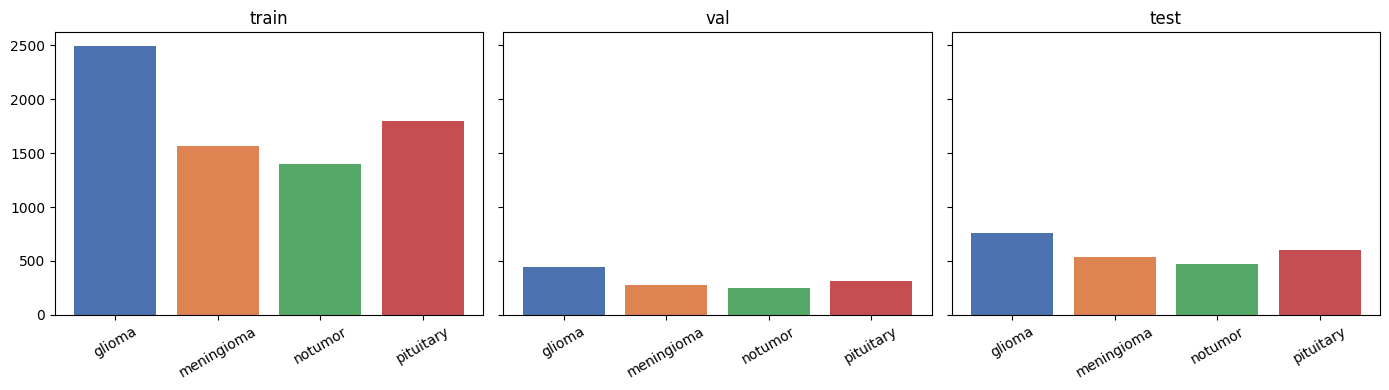

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (name, df) in zip(axes, [("train", train_df), ("val", val_df), ("test", test_df)]):
    counts = df["label"].value_counts().reindex(CLASSES)
    ax.bar(CLASSES, counts.values, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=120)
plt.show()

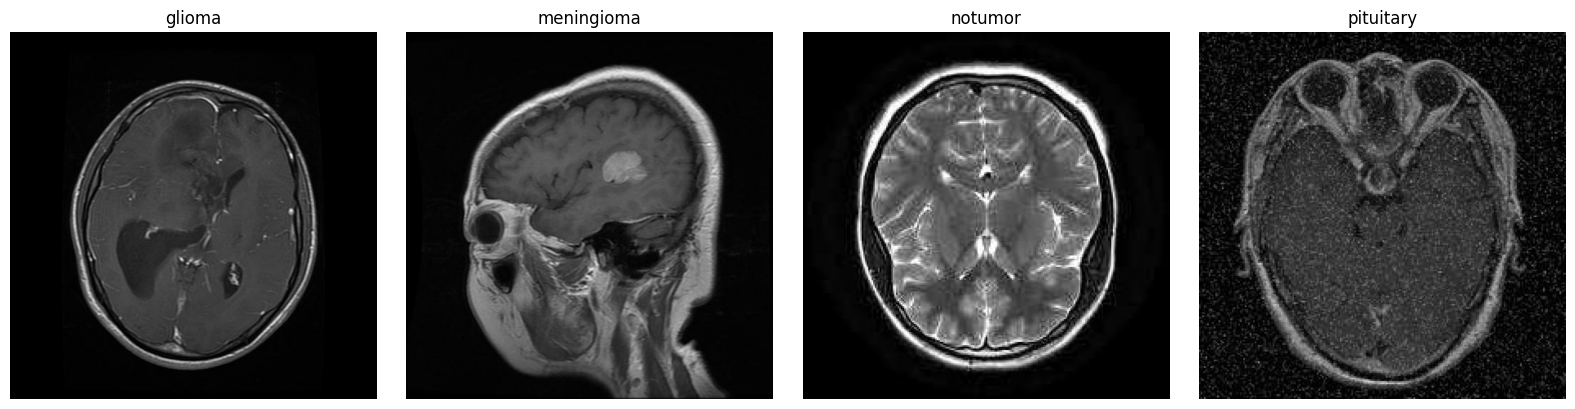

In [6]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
for ax, cls in zip(axes, CLASSES):
    row = train_df[train_df.label == cls].iloc[0]
    img = Image.open(row.path).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "sample_images.png", dpi=120)
plt.show()

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class MRIDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["path"].tolist()
        self.labels = [CLASSES.index(l) for l in df["label"]]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]


def make_loaders(batch_size):
    train_ds = MRIDataset(train_df, train_tf)
    val_ds = MRIDataset(val_df, eval_tf)
    test_ds = MRIDataset(test_df, eval_tf)
    kwargs = dict(num_workers=0, pin_memory=True)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, **kwargs),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, **kwargs),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, **kwargs),
    )


class_counts = train_df["label"].value_counts().reindex(CLASSES).values
class_weights = torch.tensor(class_counts.sum() / (len(CLASSES) * class_counts), dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(CLASSES, class_weights.tolist())))

Class weights: {'glioma': 0.7264717817306519, 'meningioma': 1.1568877696990967, 'notumor': 1.3003584146499634, 'pituitary': 1.0100222826004028}


In [8]:
def build_single(arch, pretrained=True):
    model = timm.create_model(arch, pretrained=pretrained, num_classes=NUM_CLASSES)
    return model


class GatedFusionHybrid(nn.Module):
    def __init__(self, cnn_arch="efficientnet_b0", tf_arch="swin_tiny_patch4_window7_224",
                 proj_dim=256, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        self.cnn = timm.create_model(cnn_arch, pretrained=pretrained, num_classes=0)
        self.tf = timm.create_model(tf_arch, pretrained=pretrained, num_classes=0)
        cnn_dim = self.cnn.num_features
        tf_dim = self.tf.num_features

        self.proj_a = nn.Linear(cnn_dim, proj_dim)
        self.proj_b = nn.Linear(tf_dim, proj_dim)
        self.gate = nn.Sequential(nn.Linear(proj_dim * 2, proj_dim), nn.ReLU(), nn.Linear(proj_dim, proj_dim))
        self.head = nn.Sequential(nn.LayerNorm(proj_dim), nn.Linear(proj_dim, num_classes))

        self.last_gate = None

    def forward(self, x):
        fa = self.proj_a(self.cnn(x))
        fb = self.proj_b(self.tf(x))
        g = torch.sigmoid(self.gate(torch.cat([fa, fb], dim=1)))
        self.last_gate = g.detach()
        fused = g * fa + (1 - g) * fb
        return self.head(fused)


def build_model(name):
    cfg = CONFIG[name]
    if cfg["type"] == "single":
        return build_single(cfg["arch"]).to(DEVICE)
    return GatedFusionHybrid().to(DEVICE)

In [9]:
for name in CONFIG:
    m = build_model(name)
    x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    with torch.no_grad():
        out = m(x)
    print(f"{name:8s} -> {tuple(out.shape)}")
    del m
    torch.cuda.empty_cache()

effnet   -> (2, 4)


swin     -> (2, 4)


hybrid   -> (2, 4)


coatnet  -> (2, 4)


In [10]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with autocast(device_type="cuda", enabled=DEVICE.type == "cuda"):
            out = model(x)
            loss = criterion(out, y)
        total_loss += loss.item() * x.size(0)
        all_preds += out.argmax(1).cpu().tolist()
        all_labels += y.cpu().tolist()
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(loader.dataset), acc, f1, all_preds, all_labels


def get_optimizer(name, model):
    cfg = CONFIG[name]
    if cfg["type"] == "hybrid":
        backbone_params = list(model.cnn.parameters()) + list(model.tf.parameters())
        head_params = list(model.proj_a.parameters()) + list(model.proj_b.parameters()) \
            + list(model.gate.parameters()) + list(model.head.parameters())
        return torch.optim.AdamW([
            {"params": backbone_params, "lr": cfg["backbone_lr"]},
            {"params": head_params, "lr": cfg["lr"]},
        ], weight_decay=1e-4)
    return torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)


def train_one_model(name):
    cfg = CONFIG[name]
    ckpt_dir = CKPT_DIR / name
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    history_path = ckpt_dir / "history.json"
    last_ckpt = ckpt_dir / "last.pt"

    set_seed()
    model = build_model(name)
    train_loader, val_loader, _ = make_loaders(cfg["batch_size"])
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = get_optimizer(name, model)
    scaler = GradScaler(enabled=DEVICE.type == "cuda")

    start_epoch, best_f1, history = 0, -1.0, []
    if last_ckpt.exists():
        ckpt = torch.load(last_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        start_epoch = ckpt["epoch"] + 1
        best_f1 = ckpt["best_f1"]
        history = json.loads(history_path.read_text()) if history_path.exists() else []
        print(f"[{name}] resuming from epoch {start_epoch}")

    for epoch in range(start_epoch, cfg["epochs"]):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch+1}/{cfg['epochs']}")
        for x, y in pbar:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type="cuda", enabled=DEVICE.type == "cuda"):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * x.size(0)
            pbar.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion)
        print(f"[{name}] epoch {epoch+1}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_macroF1={val_f1:.4f}")

        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1})
        history_path.write_text(json.dumps(history, indent=2))

        torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                    "epoch": epoch, "best_f1": best_f1}, last_ckpt)
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), ckpt_dir / "best.pt")

    del model
    torch.cuda.empty_cache()
    return history

In [11]:
hist_effnet = train_one_model("effnet")

[effnet] resuming from epoch 10


In [12]:
hist_swin = train_one_model("swin")

[swin] resuming from epoch 10


In [13]:
hist_hybrid = train_one_model("hybrid")

[hybrid] epoch 1/12:   0%|          | 0/303 [00:00<?, ?it/s]

[hybrid] epoch 1: train_loss=0.2671  val_loss=0.0942  val_acc=0.9703  val_macroF1=0.9693


[hybrid] epoch 2/12:   0%|          | 0/303 [00:00<?, ?it/s]

[hybrid] epoch 2: train_loss=0.0782  val_loss=0.0578  val_acc=0.9789  val_macroF1=0.9788


[hybrid] epoch 3/12:   0%|          | 0/303 [00:00<?, ?it/s]

...

[hybrid] epoch 10: train_loss=0.0215  val_loss=0.0377  val_acc=0.9890  val_macroF1=0.9887


[hybrid] epoch 11/12:   0%|          | 0/303 [00:00<?, ?it/s]

[hybrid] epoch 11: train_loss=0.0207  val_loss=0.0420  val_acc=0.9890  val_macroF1=0.9885


[hybrid] epoch 12/12:   0%|          | 0/303 [00:00<?, ?it/s]

[hybrid] epoch 12: train_loss=0.0242  val_loss=0.0473  val_acc=0.9898  val_macroF1=0.9894


In [14]:
hist_coatnet = train_one_model("coatnet")

[coatnet] epoch 1/10:   0%|          | 0/227 [00:00<?, ?it/s]

[coatnet] epoch 1: train_loss=0.4854  val_loss=0.3317  val_acc=0.8638  val_macroF1=0.8660


[coatnet] epoch 2/10:   0%|          | 0/227 [00:00<?, ?it/s]

[coatnet] epoch 2: train_loss=0.1710  val_loss=0.1110  val_acc=0.9577  val_macroF1=0.9562


[coatnet] epoch 3/10:   0%|          | 0/227 [00:00<?, ?it/s]

...

[coatnet] epoch 8: train_loss=0.0573  val_loss=0.0524  val_acc=0.9844  val_macroF1=0.9842


[coatnet] epoch 9/10:   0%|          | 0/227 [00:00<?, ?it/s]

[coatnet] epoch 9: train_loss=0.0698  val_loss=0.1291  val_acc=0.9523  val_macroF1=0.9531


[coatnet] epoch 10/10:   0%|          | 0/227 [00:00<?, ?it/s]

[coatnet] epoch 10: train_loss=0.0599  val_loss=0.1426  val_acc=0.9437  val_macroF1=0.9434


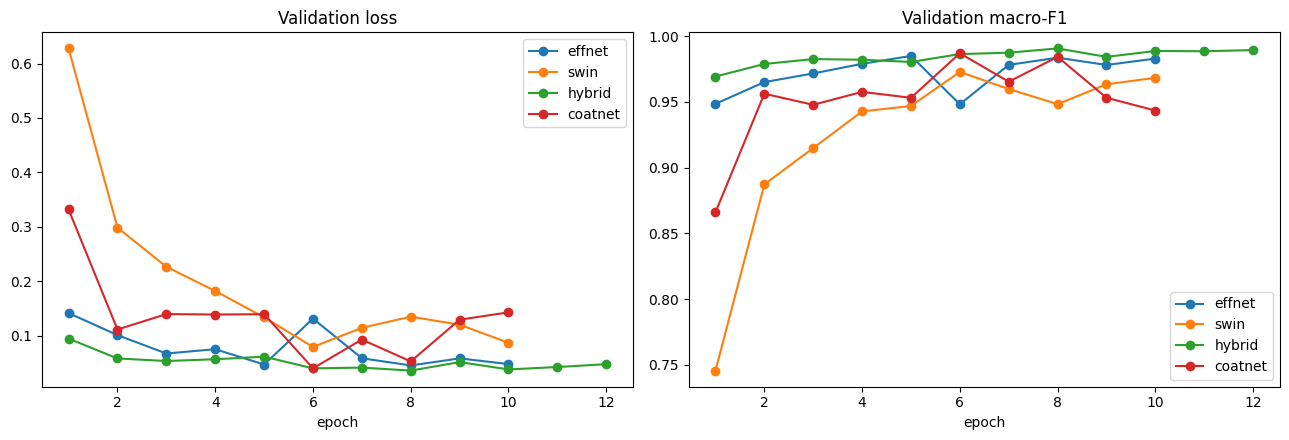

In [15]:
histories = {"effnet": hist_effnet, "swin": hist_swin, "hybrid": hist_hybrid, "coatnet": hist_coatnet}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, hist in histories.items():
    epochs = [h["epoch"] for h in hist]
    axes[0].plot(epochs, [h["val_loss"] for h in hist], marker="o", label=name)
    axes[1].plot(epochs, [h["val_f1"] for h in hist], marker="o", label=name)
axes[0].set_title("Validation loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].set_title("Validation macro-F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "training_curves.png", dpi=120)
plt.show()

In [16]:
def load_best(name):
    model = build_model(name)
    state = torch.load(CKPT_DIR / name / "best.pt", map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()
    return model


test_results = {}
confusions = {}
for name in CONFIG:
    cfg = CONFIG[name]
    _, _, test_loader = make_loaders(cfg["batch_size"])
    model = load_best(name)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    test_loss, test_acc, test_f1, preds, labels = evaluate(model, test_loader, criterion)
    per_class_recall = recall_score(labels, preds, average=None, labels=list(range(NUM_CLASSES)))
    test_results[name] = {
        "test_acc": test_acc, "test_macro_f1": test_f1,
        **{f"recall_{c}": r for c, r in zip(CLASSES, per_class_recall)},
    }
    confusions[name] = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    del model
    torch.cuda.empty_cache()

results_df = pd.DataFrame(test_results).T
results_df.to_csv(RESULTS_DIR / "test_metrics.csv")
results_df

,test_acc,test_macro_f1,recall_glioma,recall_meningioma,recall_notumor,recall_pituitary
effnet,0.957167,0.958458,0.943046,0.912639,1.000000,0.981605
swin,0.944869,0.944788,0.948344,0.860595,0.991435,0.979933
hybrid,0.966073,0.966488,0.945695,0.942379,0.997859,0.988294
coatnet,0.955895,0.956849,0.904636,0.953532,0.997859,0.989967


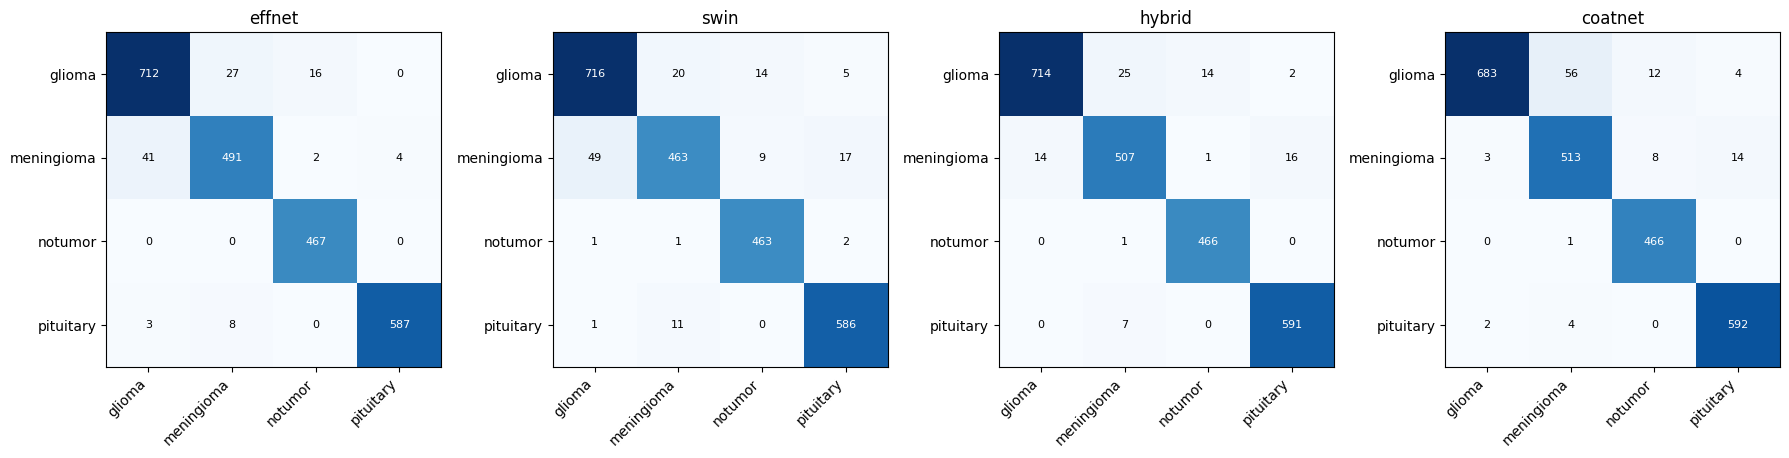

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (name, cm) in zip(axes, confusions.items()):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASSES)
    ax.set_title(name)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=120)
plt.show()

<tmp>\ipykernel_45036\2060516289.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_rows = test_df.groupby("label", group_keys=False).apply(lambda g: g.sample(1, random_state=SEED))


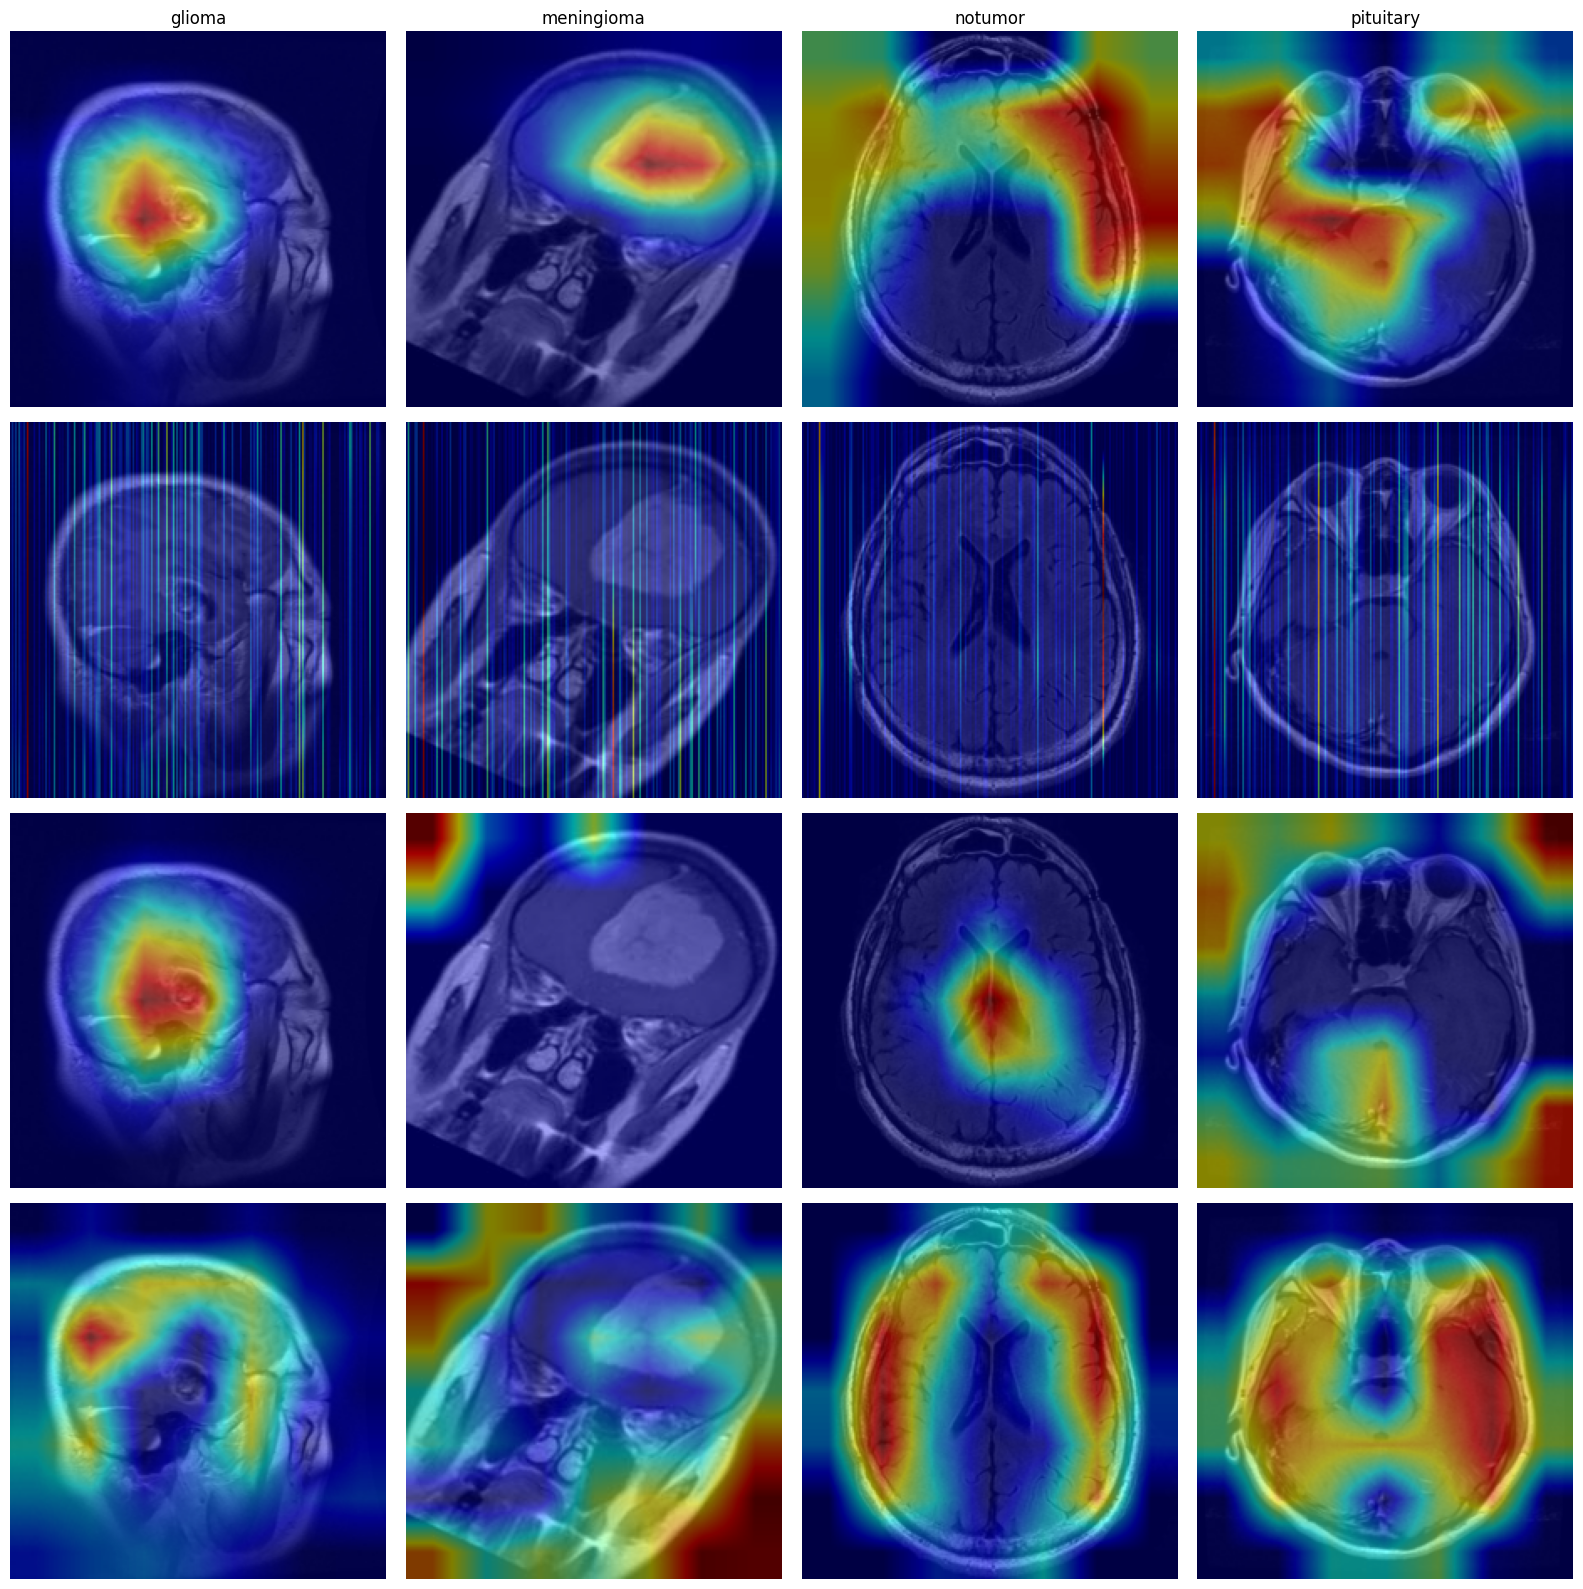

,mean_drop_cam_mask,mean_drop_random_mask,faithfulness_gap
effnet,0.496660,0.675622,-0.178963
swin,0.229695,0.113090,0.116606
hybrid,0.224590,0.731949,-0.507359
coatnet,0.037437,0.001367,0.036071


In [18]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def get_cam_target_layer(name, model):
    if name == "effnet":
        return [model.conv_head]
    if name == "swin":
        return [model.layers[-1].blocks[-1].norm1]
    if name == "coatnet":
        return [model.stages[-1]]
    if name == "hybrid":
        return [model.cnn.conv_head]
    raise ValueError(name)


def denorm(img_t):
    img = img_t.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)


sample_rows = test_df.groupby("label", group_keys=False).apply(lambda g: g.sample(1, random_state=SEED))
fig, axes = plt.subplots(len(CONFIG), NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4 * len(CONFIG)))

faithfulness_scores = {}
for row_idx, name in enumerate(CONFIG):
    model = load_best(name)
    target_layers = get_cam_target_layer(name, model)
    cam = GradCAM(model=model, target_layers=target_layers)

    drops_cam, drops_rand = [], []
    for col_idx, (_, row) in enumerate(sample_rows.iterrows()):
        img = Image.open(row.path).convert("RGB")
        x = eval_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(x)
            pred = logits.argmax(1).item()
            base_conf = F.softmax(logits, dim=1)[0, pred].item()

        grayscale_cam = cam(input_tensor=x, targets=None)[0]
        vis = show_cam_on_image(denorm(x[0]), grayscale_cam, use_rgb=True)
        axes[row_idx, col_idx].imshow(vis)
        axes[row_idx, col_idx].axis("off")
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(row.label)
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(name)

        flat = grayscale_cam.flatten()
        k = int(0.2 * flat.size)
        top_idx = np.argpartition(flat, -k)[-k:]
        rand_idx = np.random.RandomState(SEED).choice(flat.size, k, replace=False)

        def masked_conf(idx_set):
            mask = np.ones_like(flat); mask[idx_set] = 0
            mask = mask.reshape(grayscale_cam.shape)
            x_masked = x.clone()
            mask_t = torch.tensor(mask, device=DEVICE, dtype=torch.float32)
            x_masked = x_masked * mask_t
            with torch.no_grad():
                conf = F.softmax(model(x_masked), dim=1)[0, pred].item()
            return conf

        drops_cam.append(base_conf - masked_conf(top_idx))
        drops_rand.append(base_conf - masked_conf(rand_idx))

    faithfulness_scores[name] = {
        "mean_drop_cam_mask": float(np.mean(drops_cam)),
        "mean_drop_random_mask": float(np.mean(drops_rand)),
        "faithfulness_gap": float(np.mean(drops_cam) - np.mean(drops_rand)),
    }
    del model, cam
    torch.cuda.empty_cache()

plt.tight_layout()
plt.savefig(FIG_DIR / "gradcam_overlays.png", dpi=120)
plt.show()

faithfulness_df = pd.DataFrame(faithfulness_scores).T
faithfulness_df.to_csv(RESULTS_DIR / "faithfulness.csv")
faithfulness_df

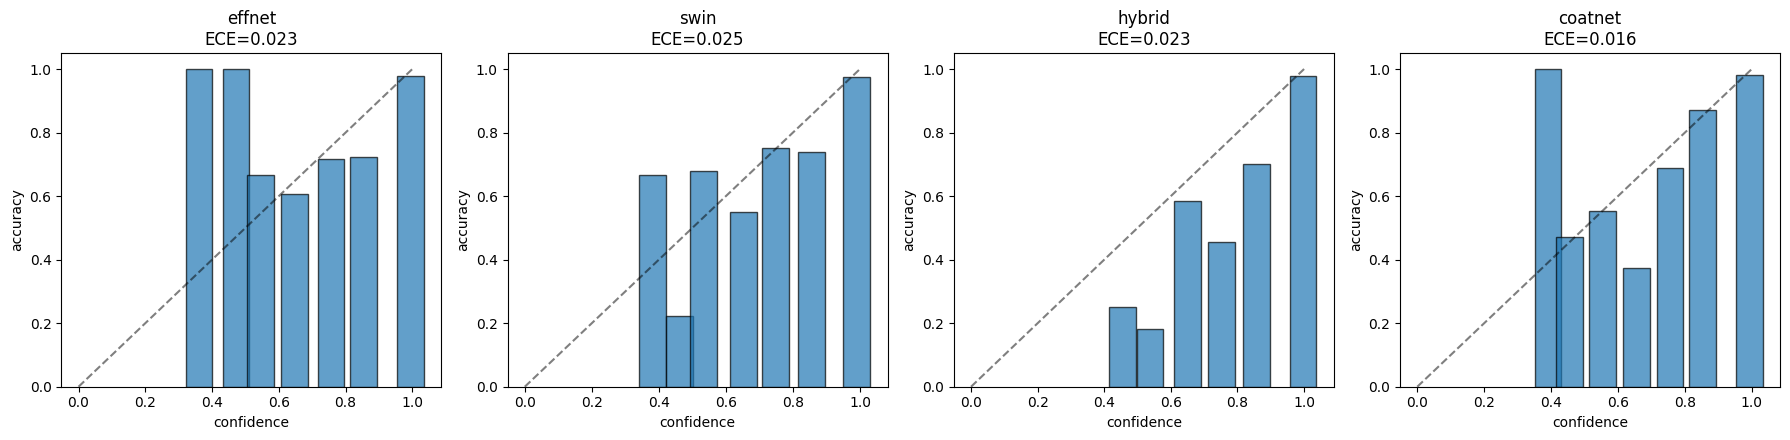

,ECE_before,ECE_after_temp_scaling,temperature
effnet,0.023256,0.023201,1.001787
swin,0.024552,0.026564,0.946762
hybrid,0.023372,0.019715,1.194081
coatnet,0.016104,0.019870,0.887369


In [19]:
def get_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            with autocast(device_type="cuda", enabled=DEVICE.type == "cuda"):
                logits = model(x)
            all_probs.append(F.softmax(logits.float(), dim=1).cpu().numpy())
            all_labels += y.tolist()
    return np.concatenate(all_probs), np.array(all_labels)


def compute_ece(probs, labels, n_bins=10):
    confidences = probs.max(1)
    preds = probs.argmax(1)
    accuracies = (preds == labels).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece, bin_stats = 0.0, []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        bin_acc = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        bin_weight = mask.sum() / len(confidences)
        ece += bin_weight * abs(bin_acc - bin_conf)
        bin_stats.append((bin_conf, bin_acc, mask.sum()))
    return ece, bin_stats


def fit_temperature(logits, labels, n_iter=200, lr=0.01):
    logits_t = torch.tensor(logits, dtype=torch.float32).to(DEVICE)
    labels_t = torch.tensor(labels, dtype=torch.long).to(DEVICE)
    temperature = torch.ones(1, requires_grad=True, device=DEVICE)
    optimizer = torch.optim.LBFGS([temperature], lr=lr, max_iter=n_iter)

    def closure():
        optimizer.zero_grad()
        loss = F.cross_entropy(logits_t / temperature, labels_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    return temperature.item()


fig, axes = plt.subplots(1, len(CONFIG), figsize=(4.5 * len(CONFIG), 4.5))
calibration_results = {}
for ax, name in zip(axes, CONFIG):
    cfg = CONFIG[name]
    _, val_loader, test_loader = make_loaders(cfg["batch_size"])
    model = load_best(name)

    val_probs, val_labels = get_probs_labels(model, val_loader)
    test_probs, test_labels = get_probs_labels(model, test_loader)

    ece_before, bin_stats = compute_ece(test_probs, test_labels)

    val_logits = np.log(np.clip(val_probs, 1e-8, 1)) + 1
    T_opt = fit_temperature(val_logits, val_labels)
    test_logits_approx = np.log(np.clip(test_probs, 1e-8, 1)) + 1
    test_probs_scaled = F.softmax(torch.tensor(test_logits_approx / T_opt, dtype=torch.float32), dim=1).numpy()
    ece_after, _ = compute_ece(test_probs_scaled, test_labels)

    calibration_results[name] = {"ECE_before": ece_before, "ECE_after_temp_scaling": ece_after, "temperature": T_opt}

    confs = [b[0] for b in bin_stats]
    accs = [b[1] for b in bin_stats]
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.bar(confs, accs, width=0.08, alpha=0.7, edgecolor="black")
    ax.set_title(f"{name}\nECE={ece_before:.3f}")
    ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")

    del model
    torch.cuda.empty_cache()

plt.tight_layout()
plt.savefig(FIG_DIR / "reliability_diagrams.png", dpi=120)
plt.show()

calibration_df = pd.DataFrame(calibration_results).T
calibration_df.to_csv(RESULTS_DIR / "calibration.csv")
calibration_df

In [20]:
final_table = results_df.join(faithfulness_df[["faithfulness_gap"]]).join(calibration_df[["ECE_before", "ECE_after_temp_scaling"]])
final_table.to_csv(RESULTS_DIR / "final_comparison.csv")
final_table

,test_acc,test_macro_f1,recall_glioma,recall_meningioma,recall_notumor,recall_pituitary,faithfulness_gap,ECE_before,ECE_after_temp_scaling
effnet,0.957167,0.958458,0.943046,0.912639,1.000000,0.981605,-0.178963,0.023256,0.023201
swin,0.944869,0.944788,0.948344,0.860595,0.991435,0.979933,0.116606,0.024552,0.026564
hybrid,0.966073,0.966488,0.945695,0.942379,0.997859,0.988294,-0.507359,0.023372,0.019715
coatnet,0.955895,0.956849,0.904636,0.953532,0.997859,0.989967,0.036071,0.016104,0.019870
